In [1]:
# Reference: https://jakevdp.github.io/PythonDataScienceHandbook/05.05-naive-bayes.html

# Import all necessary libraries.
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
# Use the 20 Newsgroups corpus from scikit to show how we might classify these short documents into categories.
data = fetch_20newsgroups()
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [3]:
# Select just a few of these categories, and download the training and testing set.
categories = ['talk.religion.misc', 'soc.religion.christian', 'sci.space', 'comp.graphics']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

In [4]:
# Convert a collection of text documents to a matrix of token counts.
cv = CountVectorizer()
# Naive Bayes classifier for multinomial models.
mnb = MultinomialNB()
# Create a pipeline that attaches the vectorizer to a multinomial naive Bayes classifier.
model = make_pipeline(cv, mnb)

In [5]:
# Train model. Apply the model to the training data.
model.fit(train.data, train.target)
# Run validation. Predict labels for the test data.
labels = model.predict(test.data)

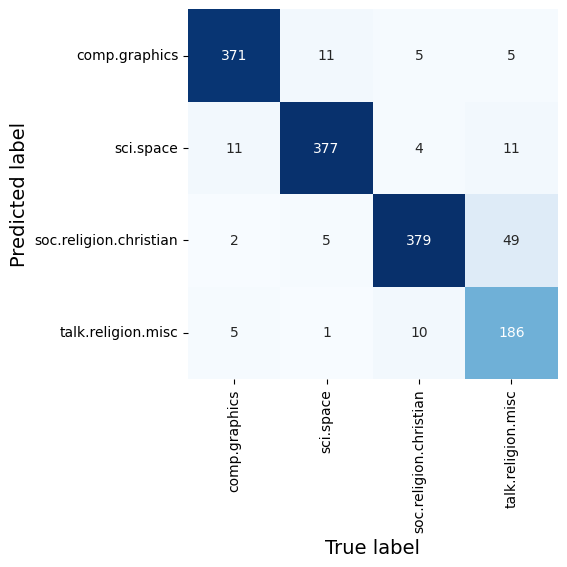

In [6]:
# Evaluate the model's performance with the confusion matrix between the true and predicted labels for the test data.
mat = confusion_matrix(test.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, xticklabels=train.target_names, yticklabels=train.target_names, cmap="Blues")
plt.xlabel('True label', fontsize=14)
plt.ylabel('Predicted label', fontsize=14)
# Save figure
#plt.savefig("confusion_matrix_text_classification.png", dpi=600)
plt.show()

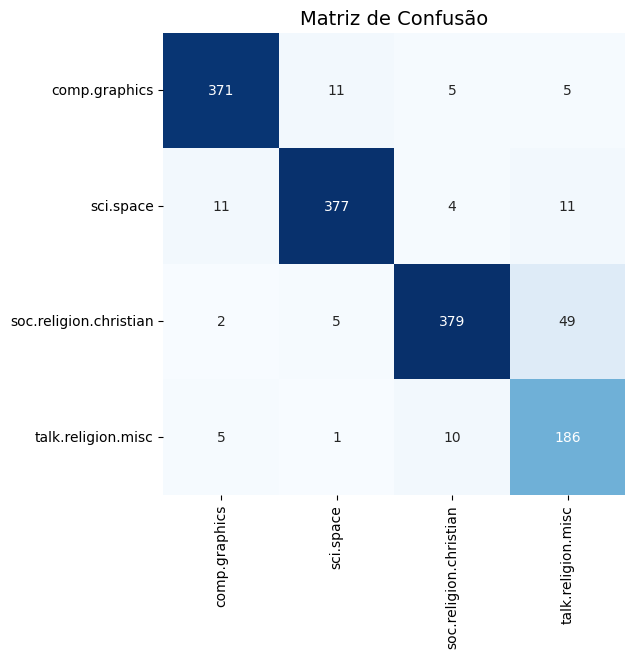

-------------------------------------------------------------------------
                        precision    recall  f1-score   support

         comp.graphics       0.95      0.95      0.95       389
             sci.space       0.94      0.96      0.95       394
soc.religion.christian       0.87      0.95      0.91       398
    talk.religion.misc       0.92      0.74      0.82       251

              accuracy                           0.92      1432
             macro avg       0.92      0.90      0.91      1432
          weighted avg       0.92      0.92      0.92      1432

Texto exemplo: 'The spacecraft is in orbit around Earth.'
Categoria prevista: sci.space


In [10]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report


categories = ['talk.religion.misc', 'soc.religion.christian', 'sci.space', 'comp.graphics']


train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)


model = make_pipeline(CountVectorizer(), MultinomialNB())


model.fit(train.data, train.target)


y_pred = model.predict(test.data)
y_true = test.target


plt.figure(figsize=(8, 6))
mat = confusion_matrix(y_true, y_pred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=train.target_names,
            yticklabels=train.target_names,
            cmap="Blues")
plt.title("Matriz de Confusão", fontsize=14)
plt.show()


from sklearn.metrics import classification_report
print("-------------------------------------------------------------------------")
print(classification_report(y_true, y_pred, target_names=train.target_names))


def predict_category(text, model=model, train=train):
    pred = model.predict([text])[0]
    return train.target_names[pred]


example = "The spacecraft is in orbit around Earth."
print(f"Texto exemplo: '{example}'")
print(f"Categoria prevista: {predict_category(example)}")
